# Filtrado colaborativo con KNN en el dataset Food.com

Estudiaremos cómo construir un sistema de recomendación basado en filtrado colaborativo utilizando KNN sobre el conjunto de datos de Food.com. Partiremos de las valoraciones de usuarios sobre recetas para generar una matriz dispersa de interacciones (utilizando ```scipy.sparse```), calcularemos similitudes entre usuarios con medidas como la correlación de Pearson o la métrica JMSD y, a partir de los vecinos más cercanos, realizaremos predicciones de ratings y recomendaciones Top‑N. Finalmente evaluaremos el rendimiento con métricas de error (MAE, RMSE) y de ranking (precisión, recall, F1, NDCG) para analizar la calidad de nuestras recomendaciones.

**Autores:** Gallo Álvaro, García Álvaro, Recover Diego, Rízquez Tello

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).


In [3]:
# Librerías utilizadas

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

In [4]:
# Cargamos los datos
train_clean = pd.read_csv("../data/processed/interactions_train_clean.csv")
test_clean = pd.read_csv("../data/processed/interactions_test_clean.csv")

In [5]:
# Definimos las constantes conocidas
NUM_USERS = int(max(train_clean["u"].max(), test_clean["u"].max())) + 1
NUM_ITEMS = int(max(train_clean["i"].max(), test_clean["i"].max())) + 1

MIN_RATING = 1
MAX_RATING = 5

print(NUM_ITEMS, NUM_USERS)

178265 25076


## Matriz de interacciones y representación dispersa

El filtrado colaborativo basado en memoria necesita una matriz de usuario × ítem que refleje las valoraciones observadas para poder calcular similitudes y predicciones. Dado que en Food.com sólo una pequeña fracción de las posibles combinaciones usuario‑receta está valorada, se recurre a una representación dispersa (```scipy.sparse```) en la que sólo se almacenan los ratings distintos de cero. Esta estructura ahorra memoria y permite operaciones eficientes en comparación con una matriz densa, ya que el número total de usuarios y recetas es grande. 


In [6]:
# Construimos la matriz de interacciones para 'train'
# Nota: Se ha creado una matriz dispersa para optimizar el almacenamiento y la eficiencia de las operaciones posteriores.

ratings = csr_matrix(

    (train_clean["rating"].astype(float).values,

     (train_clean["u"].astype(int).values, train_clean["i"].astype(int).values)),

    shape=(NUM_USERS, NUM_ITEMS)

)

print(f"Dimensión de la matriz sparse de train_clean: {ratings.shape}")
print(f"Número de valores almacenados: {ratings.nnz}")

Dimensión de la matriz sparse de train_clean: (25076, 178265)
Número de valores almacenados: 698901


In [7]:
# Construimos la matriz de interacciones para 'test'
# Nota: Se ha creado una matriz dispersa para optimizar el almacenamiento y la eficiencia de las operaciones posteriores.

test_ratings = csr_matrix(

    (test_clean["rating"].astype(float).values,

     (test_clean["u"].astype(int).values, test_clean["i"].astype(int).values)),

    shape=(NUM_USERS, NUM_ITEMS)

)

print(f"Dimensión de la matriz sparse de test_clean: {test_ratings.shape}")
print(f"Número de valores almacenados: {test_ratings.nnz}")

Dimensión de la matriz sparse de test_clean: (25076, 178265)
Número de valores almacenados: 12455


In [8]:
# Función para calcular el promedio de las calificaciones de un usuario

def rating_average(mat: csr_matrix, u: int):
    row = mat.getrow(u)
    if row.nnz == 0:
        return None
    return float(row.data.mean())

## Similitud basada en correlación de Pearson

Para encontrar usuarios similares utilizaremos la correlación de Pearson, que mide la relación lineal entre dos vectores de valoraciones. La función recibe las filas de la matriz dispersa correspondientes a dos usuarios, identifica los ítems que ambos han valorado y, si hay suficiente solapamiento, calcula la covarianza entre sus desviaciones respecto a sus medias dividiéndola por el producto de sus desviaciones estándar. Así se obtiene un coeficiente entre $−1$ y $1$ que indica afinidad: valores positivos significan que los usuarios tienden a puntuar los mismos ítems por encima o por debajo de su media, mientras que valores cercanos a cero indican poca relación. Si no hay suficientes ítems en común o la varianza es nula, la similitud se descarta.


In [9]:
def correlation_similarity(mat: csr_matrix, u: int, v: int, min_common: int = 3):
    row_u = mat.getrow(u)
    row_v = mat.getrow(v)

    if row_u.nnz == 0 or row_v.nnz == 0:
        return None

    avg_u = rating_average(mat, u)
    avg_v = rating_average(mat, v)
    if avg_u is None or avg_v is None:
        return None

    # Índices de ítems valorados por cada usuario
    idx_u = row_u.indices
    idx_v = row_v.indices

    # Ítems en común + posiciones dentro de cada fila
    common_items, pos_u, pos_v = np.intersect1d(idx_u, idx_v, assume_unique=False, return_indices=True)

    if common_items.size < min_common:
        return None

    # Ratings solo en los ítems comunes
    ru = row_u.data[pos_u]
    rv = row_v.data[pos_v]

    du = ru - avg_u
    dv = rv - avg_v

    num = float(np.dot(du, dv))
    den_u = float(np.dot(du, du))
    den_v = float(np.dot(dv, dv))

    if den_u > 0 and den_v > 0:
        return num / np.sqrt(den_u * den_v)
    return None

In [10]:
# Ejemplos de similitud entre usuarios utilizando la función de correlación
print(correlation_similarity(ratings, 909, 235))
print(correlation_similarity(ratings, 5, 819))
print(correlation_similarity(ratings, 92, 355))

1.0
-0.390097991545325
None


## Métrica JMSD: combinación de Jaccard y Mean Squared Difference (MSD)

La correlación ignora cuántos ítems comparten los usuarios y puede ser poco robusta en escenarios muy dispersos, por lo que se proponen métricas híbridas. JMSD calcula, por un lado, el coeficiente de Jaccard, es decir, el cociente entre el número de ítems valorados en común y el tamaño de la unión. Por otro lado, normaliza las valoraciones al rango $[0,\,1]$ y calcula el Mean Squared Difference (MSD), la media de las diferencias al cuadrado entre las puntuaciones normalizadas. Finalmente, multiplica el Jaccard por $1 - \mathrm{MSD}$ para penalizar grandes discrepancias en las valoraciones. De esta manera se recompensa el solapamiento elevado y se favorecen pares de usuarios que, además de valorar muchos ítems comunes, lo hacen con valores similares.


In [11]:
def jmsd_similarity(mat, u, v, min_common=1):
    row_u = mat.getrow(u)
    row_v = mat.getrow(v)

    if row_u.nnz == 0 or row_v.nnz == 0:
        return None

    idx_u = row_u.indices
    idx_v = row_v.indices

    # Intersección y unión (en términos de ítems valorados)
    common_items, pos_u, pos_v = np.intersect1d(idx_u, idx_v, return_indices=True, assume_unique=False)
    union_count = np.union1d(idx_u, idx_v).size
    inter_count = common_items.size

    if inter_count < min_common or union_count == 0:
        return None

    # Ratings normalizados en ítems comunes
    ru = row_u.data[pos_u].astype(float)
    rv = row_v.data[pos_v].astype(float)

    ru_n = (ru - MIN_RATING) / (MAX_RATING - MIN_RATING)
    rv_n = (rv - MIN_RATING) / (MAX_RATING - MIN_RATING)

    # Definimos MSD como la media de las diferencias al cuadrado entre los ratings normalizados
    diff_sq = (ru_n - rv_n) ** 2
    msd = float(diff_sq.mean())  

    jaccard = inter_count / union_count
    return float(jaccard * (1 - msd))

In [12]:
# Ejemplos de similitud entre usuarios utilizando la función de jaccard
print(jmsd_similarity(ratings, 909, 235))
print(jmsd_similarity(ratings, 5, 819))
print(jmsd_similarity(ratings, 92, 355))

0.004410143329658214
0.004434404283801874
None


## Elección del número de vecinos $k$

El algoritmo KNN requiere fijar cuántos vecinos considerar al calcular predicciones. Un valor pequeño de $k$ concentra la atención en los usuarios más parecidos, pero puede ser sensible al ruido o a la falta de solapamiento; un valor grande produce predicciones más estables pero incorpora a usuarios menos relevantes. Hemos elegido un valor de $k=25$, para cada usuario se buscarán sus 25 vecinos más similares según la métrica de similitud seleccionada y se utilizarán para predecir nuevas valoraciones y generar recomendaciones.


In [13]:
k = 25

In [14]:
def get_neighbors (u, similarities):

  neighbors = [None for _ in range(k)]

  for n in range(k):

    max_similarity = 0
    neighbor = None

    for v, sim in enumerate(similarities):
      if v not in neighbors and sim != None and sim > max_similarity:
        max_similarity = sim
        neighbor = v

    neighbors[n] = neighbor

  return neighbors

In [15]:
# Testing
u = 112
similarities_corr = [None if u == v else correlation_similarity(ratings, u, v) for v in range(NUM_USERS)]
similarities_jmsd = [None if u == v else jmsd_similarity(ratings, u, v) for v in range(NUM_USERS)]
neighbors_corr = get_neighbors(u, similarities_corr)
neighbors_jmsd = get_neighbors(u, similarities_jmsd)
print(neighbors_corr)
print(neighbors_jmsd)

[184, 295, 663, 37, 89, 120, 130, 238, 241, 288, 338, 350, 396, 452, 470, 515, 546, 590, 746, 857, 937, 991, 1091, 1239, 1258]
[2013, 619, 1192, 231, 1483, 3624, 506, 2202, 104, 376, 2052, 135, 546, 353, 4964, 5904, 2032, 8, 396, 238, 1390, 1783, 77, 2106, 3]


## Número de ítems en común

Antes de calcular una similitud conviene conocer cuántos ítems han valorado ambos usuarios. La función auxiliar `num_common_items_sparse` recurre a las estructuras internas de la matriz dispersa para obtener rápidamente las listas de índices de ítems valorados por cada usuario y calcula la intersección de estas listas. El tamaño de esa intersección se utiliza tanto para descartar pares sin solapamiento como para calcular coeficientes como el de Jaccard. Un alto número de ítems en común suele dar más fiabilidad a las medidas de similitud y a las predicciones basadas en vecinos.


In [16]:
def num_common_items_sparse(mat, u, v):
    row_u = mat.getrow(u)
    row_v = mat.getrow(v)
    if row_u.nnz == 0 or row_v.nnz == 0:
        return 0
    return np.intersect1d(row_u.indices, row_v.indices).size

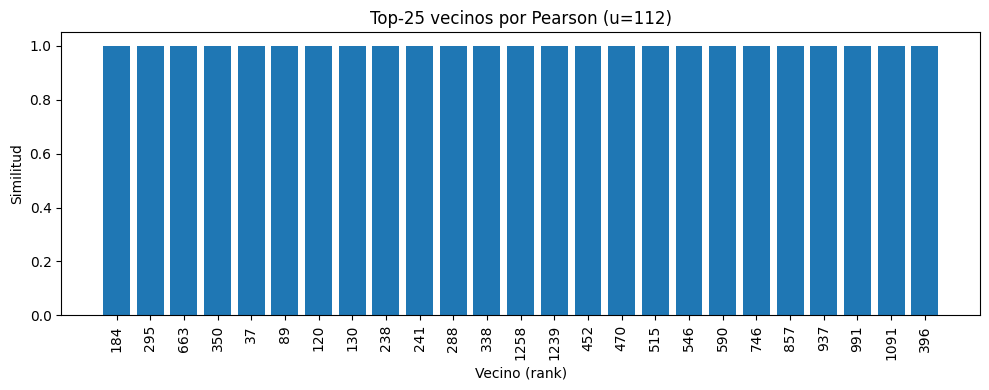

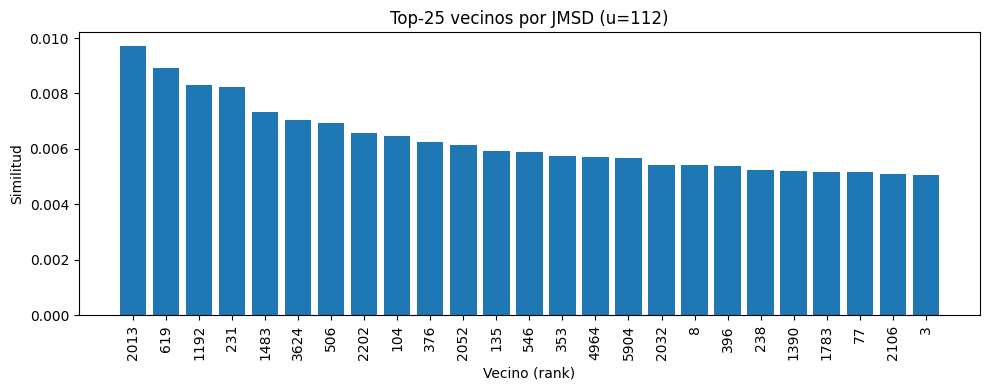

In [17]:
def plot_topk_similarities(u, neighbors, similarities, title):
    sims = [similarities[v] for v in neighbors if v is not None]
    neighs = [v for v in neighbors if v is not None]

    # ordenar por similitud
    order = np.argsort(sims)[::-1]
    sims = np.array(sims)[order]
    neighs = np.array(neighs)[order]

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(neighs)), sims)
    plt.title(title)
    plt.xlabel("Vecino (rank)")
    plt.ylabel("Similitud")
    plt.xticks(range(len(neighs)), neighs, rotation=90)
    plt.tight_layout()
    plt.show()

plot_topk_similarities(u, neighbors_corr, similarities_corr, f"Top-{k} vecinos por Pearson (u={u})")
plot_topk_similarities(u, neighbors_jmsd, similarities_jmsd, f"Top-{k} vecinos por JMSD (u={u})")

## Predicción como media simple de vecinos

Una vez identificados los vecinos de un usuario, la forma más sencilla de predecir su valoración de un ítem es tomar la media aritmética de las valoraciones de esos vecinos para ese ítem. La función `average_prediction` recorre la lista de vecinos, acumula las puntuaciones que realmente han dado al ítem y divide por el número de vecinos que lo han valorado. Si ninguno de los vecinos ha puntuado el ítem, devuelve `None`.


In [18]:
import numpy as np

def average_prediction(mat, u, i, neighbors):
    acc = 0.0
    count = 0

    for n in neighbors:
        if n is None:
            break

        r = mat[n, i]  # en las matrices sparse se devuelve un escalar (0 si no existe)
        if r != 0:
            acc += float(r)
            count += 1

    if count > 0:
        return acc / count
    else:
        return None

In [19]:
u = 112
i = 324

In [20]:
avgpred_corr = average_prediction(ratings, u, i, neighbors_corr)
avgpred_jmsd = average_prediction(ratings, u, i, neighbors_jmsd)

print(avgpred_corr)
print(avgpred_jmsd)

5.0
5.0


In [21]:
def weighted_average_prediction(mat, i, neighbors, similarities):
    num = 0.0
    den = 0.0

    for n in neighbors:
        if n is None:
            break

        r = mat[n, i]  # 0 si no existe
        if r != 0:
            sim = similarities[n]
            if sim is None:
                continue

            # (opcional pero recomendable) ignorar similitudes negativas
            if sim <= 0:
                continue

            num += float(sim) * float(r)
            den += float(sim)

    if den > 0:
        return num / den
    else:
        return None

In [22]:
wavgpred_corr = weighted_average_prediction(ratings, i, neighbors_corr, similarities_corr)
wavgpred_jmsd = weighted_average_prediction(ratings, i, neighbors_jmsd, similarities_jmsd)

print(wavgpred_corr)
print(wavgpred_jmsd)

5.0
5.0


In [23]:
def deviation_from_mean_prediction(mat, u, i, neighbors):
    acc = 0.0
    count = 0

    for n in neighbors:
        if n is None:
            break

        r = mat[n, i]  # 0 si no existe
        if r != 0:
            avg_n = rating_average(mat, n)
            if avg_n is None:
                continue

            acc += float(r) - avg_n
            count += 1

    if count > 0:
        avg_u = rating_average(mat, u)
        if avg_u is None:
            return None
        return avg_u + acc / count
    else:
        return None

In [24]:
dfmpred_corr = deviation_from_mean_prediction(ratings, u, i, neighbors_corr)
dfmpred_jmsd = deviation_from_mean_prediction(ratings, u, i, neighbors_jmsd)

print(dfmpred_corr)
print(dfmpred_jmsd)

4.5082993593477
4.5082993593477


## Tamaño del listado de recomendaciones

En la evaluación de sistemas de recomendación se suele generar un listado de los $N$ ítems con mayor puntuación predicha para cada usuario. El parámetro `N` controla la longitud de ese ranking. Fijamos en este notebook $N=5$ para algunos ejemplos, lo que significa que solo se considerarán las cinco mejores recomendaciones por usuario al calcular métricas como precisión@N o recall@N. 

In [25]:
N = 5

In [26]:
def get_recommendations(predictions, N=10):
    recommendations = [None for _ in range(N)]

    for n in range(N):
        max_value = -float("inf")
        item = None

        for i, value in enumerate(predictions):
            if i not in recommendations and value is not None and value > max_value:
                max_value = value
                item = i

        recommendations[n] = item

    return recommendations

def candidate_items_from_neighbors(mat, u, neighbors):
    """
    Candidatos = unión de ítems valorados por los vecinos
    menos los ítems que ya valoró el usuario u.
    """
    user_items = set(mat.getrow(u).indices)  # ítems ya vistos por u
    cand = set()

    for n in neighbors:
        if n is None:
            break
        cand.update(mat.getrow(n).indices)

    cand.difference_update(user_items)
    return sorted(cand)

def topN_from_candidates(candidates, preds, N=10):
    rec_pos = get_recommendations(preds, N=N)          # posiciones en preds
    rec_items = [candidates[p] if p is not None else None for p in rec_pos]
    return rec_items

def predict_for_candidates_avg(mat, u, neighbors, candidates):
    # vector de predicciones del mismo tamaño que candidates
    preds = [average_prediction(mat, u, i, neighbors) for i in candidates]
    return preds

def predict_for_candidates_wavg(mat, neighbors, similarities, candidates):
    preds = [weighted_average_prediction(mat, i, neighbors, similarities) for i in candidates]
    return preds

def predict_for_candidates_dfm(mat, u, neighbors, candidates):
    preds = [deviation_from_mean_prediction(mat, u, i, neighbors) for i in candidates]
    return preds

In [27]:
N = 10
u = 112

# Candidatos (items que los vecinos han puntuado y u no)
candidates_corr = candidate_items_from_neighbors(ratings, u, neighbors_corr)
candidates_jmsd = candidate_items_from_neighbors(ratings, u, neighbors_jmsd)

# --- AVG ---
avg_preds_corr = predict_for_candidates_avg(ratings, u, neighbors_corr, candidates_corr)
avg_preds_jmsd = predict_for_candidates_avg(ratings, u, neighbors_jmsd, candidates_jmsd)

recs_avg_corr = topN_from_candidates(candidates_corr, avg_preds_corr, N=N)
recs_avg_jmsd = topN_from_candidates(candidates_jmsd, avg_preds_jmsd, N=N)

# --- Weighted AVG ---
wavg_preds_corr = predict_for_candidates_wavg(ratings, neighbors_corr, similarities_corr, candidates_corr)
wavg_preds_jmsd = predict_for_candidates_wavg(ratings, neighbors_jmsd, similarities_jmsd, candidates_jmsd)

recs_wavg_corr = topN_from_candidates(candidates_corr, wavg_preds_corr, N=N)
recs_wavg_jmsd = topN_from_candidates(candidates_jmsd, wavg_preds_jmsd, N=N)

# --- Deviation from mean ---
dfm_preds_corr = predict_for_candidates_dfm(ratings, u, neighbors_corr, candidates_corr)
dfm_preds_jmsd = predict_for_candidates_dfm(ratings, u, neighbors_jmsd, candidates_jmsd)

recs_dfm_corr = topN_from_candidates(candidates_corr, dfm_preds_corr, N=N)
recs_dfm_jmsd = topN_from_candidates(candidates_jmsd, dfm_preds_jmsd, N=N)

print("AVG corr:", recs_avg_corr)
print("AVG jmsd:", recs_avg_jmsd)
print("WAVG corr:", recs_wavg_corr)
print("WAVG jmsd:", recs_wavg_jmsd)
print("DFM corr:", recs_dfm_corr)
print("DFM jmsd:", recs_dfm_jmsd)

AVG corr: [np.int32(12), np.int32(45), np.int32(51), np.int32(77), np.int32(78), np.int32(92), np.int32(96), np.int32(98), np.int32(99), np.int32(112)]
AVG jmsd: [np.int32(2), np.int32(3), np.int32(26), np.int32(36), np.int32(53), np.int32(95), np.int32(98), np.int32(152), np.int32(153), np.int32(156)]
WAVG corr: [np.int32(12), np.int32(45), np.int32(51), np.int32(77), np.int32(78), np.int32(92), np.int32(96), np.int32(98), np.int32(99), np.int32(112)]
WAVG jmsd: [np.int32(976), np.int32(1074), np.int32(3352), np.int32(4086), np.int32(4091), np.int32(4881), np.int32(6773), np.int32(7649), np.int32(9107), np.int32(9463)]
DFM corr: [np.int32(203), np.int32(5148), np.int32(5415), np.int32(5817), np.int32(9281), np.int32(11241), np.int32(12912), np.int32(15158), np.int32(16848), np.int32(17073)]
DFM jmsd: [np.int32(476), np.int32(2217), np.int32(4344), np.int32(5781), np.int32(7739), np.int32(8185), np.int32(12266), np.int32(16736), np.int32(19705), np.int32(20910)]


## Comprobación de usuarios con datos en el conjunto de test

Para evaluar correctamente nuestras predicciones necesitamos usuarios que tengan valoraciones en el conjunto de test. La función `has_test_ratings` comprueba si un usuario dado tiene al menos un rating en `ratings` (la matriz de test). Este filtro evita computar métricas sobre usuarios sin datos de referencia, lo que sesgaría los resultados. 

In [28]:
def has_test_ratings(u, ratings):
    """True si el usuario u tiene al menos un rating en TEST."""
    return ratings.getrow(u).nnz > 0

In [29]:

MAX_TEST_USERS = 100          # solo evaluamos estos usuarios de test
MAX_CANDIDATES = 2000         # nº máximo de candidatos v por usuario (reduce muchísimo el coste computacional)
MIN_COMMON = 2                # mínimo de ítems comunes para similitudes

# Guardamos predicciones solo para (u,i) que están en test
avg_predictions_corr = {}
avg_predictions_jmsd = {}
wavg_predictions_corr = {}
wavg_predictions_jmsd = {}
dfm_predictions_corr = {}
dfm_predictions_jmsd = {}

train_csc = ratings.tocsc()

# Usuarios que aparecen en test
test_users = np.unique(ratings.nonzero()[0])
test_users = test_users[:min(MAX_TEST_USERS, len(test_users))]

print("Usuarios test evaluados:", len(test_users))

for u in test_users:
    u = int(u)

    
    # Candidatos v: usuarios que comparten al menos 1 ítem con u
    user_items = ratings.getrow(u).indices
    if user_items.size == 0:
        continue

    candidates = set()
    for it in user_items:
        candidates.update(train_csc.getcol(int(it)).indices.tolist())
    candidates.discard(u)

    candidates = list(candidates)
    if len(candidates) == 0:
        continue

    # Limitar número de candidatos para que sea barato
    if len(candidates) > MAX_CANDIDATES:
        candidates = list(np.random.choice(candidates, size=MAX_CANDIDATES, replace=False))

    # Similaridades (lista tamaño NUM_USERS, None salvo candidatos)
    similarities_corr = [None] * NUM_USERS
    similarities_jmsd = [None] * NUM_USERS

    for v in candidates:
        v = int(v)
        similarities_corr[v] = correlation_similarity(ratings, u, v, min_common=MIN_COMMON)
        similarities_jmsd[v] = jmsd_similarity(ratings, u, v, min_common=MIN_COMMON)

    # Vecinos top-k  
    neighbors_corr = get_neighbors(u, similarities_corr)
    neighbors_jmsd = get_neighbors(u, similarities_jmsd)

    # Predecir SOLO sobre ítems que el usuario tiene en test
    row_test = ratings.getrow(u)
    test_items = row_test.indices  # ítems evaluados en test

    for i in test_items:
        i = int(i)

        # Average
        avg_predictions_corr[(u, i)] = average_prediction(ratings, u, i, neighbors_corr)
        avg_predictions_jmsd[(u, i)] = average_prediction(ratings, u, i, neighbors_jmsd)

        # Weighted average
        wavg_predictions_corr[(u, i)] = weighted_average_prediction(ratings, i, neighbors_corr, similarities_corr)
        wavg_predictions_jmsd[(u, i)] = weighted_average_prediction(ratings, i, neighbors_jmsd, similarities_jmsd)

        # Deviation from mean
        dfm_predictions_corr[(u, i)] = deviation_from_mean_prediction(ratings, u, i, neighbors_corr)
        dfm_predictions_jmsd[(u, i)] = deviation_from_mean_prediction(ratings, u, i, neighbors_jmsd)

Usuarios test evaluados: 100


In [30]:
def get_user_mae(u, preds_dict, ratings):      
    row = ratings.getrow(u)
    items = row.indices
    true_ratings = row.data

    acc = 0.0
    count = 0   

    for idx, i in enumerate(items):
        i = int(i)
        true_r = float(true_ratings[idx])
        pred = preds_dict.get((u, i), None)
        if pred is not None:
            acc += abs(true_r - pred)
            count += 1

    return (acc / count) if count > 0 else None

In [31]:
def get_mae(preds_dict, ratings, users_subset):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        user_mae = get_user_mae(u, preds_dict, ratings)
        if user_mae is not None:
            acc += user_mae
            count += 1

    return (acc / count) if count > 0 else None

In [32]:
mae_avg_corr  = get_mae(avg_predictions_corr,  ratings, test_users)
mae_avg_jmsd  = get_mae(avg_predictions_jmsd,  ratings, test_users)
mae_wavg_corr = get_mae(wavg_predictions_corr, ratings, test_users)
mae_wavg_jmsd = get_mae(wavg_predictions_jmsd, ratings, test_users)
mae_dfm_corr  = get_mae(dfm_predictions_corr,  ratings, test_users)
mae_dfm_jmsd  = get_mae(dfm_predictions_jmsd,  ratings, test_users)

print("MAE Avg Prediction with Corr Similarity = " + str(mae_avg_corr))
print("MAE Avg Prediction with JMSD Similarity = " + str(mae_avg_jmsd))
print("MAE Weighted Avg Prediction with Corr Similarity = " + str(mae_wavg_corr))
print("MAE Weighted Avg Prediction with JMSD Similarity = " + str(mae_wavg_jmsd))
print("MAE Dev from Mean Prediction with Corr Similarity = " + str(mae_dfm_corr))
print("MAE Dev from Mean Prediction with JMSD Similarity = " + str(mae_dfm_jmsd))

MAE Avg Prediction with Corr Similarity = 0.1401397841157715
MAE Avg Prediction with JMSD Similarity = 0.4698595648296205
MAE Weighted Avg Prediction with Corr Similarity = 0.13507392101980542
MAE Weighted Avg Prediction with JMSD Similarity = 0.4691244996302401
MAE Dev from Mean Prediction with Corr Similarity = 0.2888999093419775
MAE Dev from Mean Prediction with JMSD Similarity = 0.5135437035400254


## Cálculo del error RMSE

El error cuadrático medio raíz (RMSE) es una métrica utilizada para evaluar la exactitud de un predictor. Para un usuario concreto, la función `get_user_rmse` recupera los ítems presentes en el conjunto de test, compara las valoraciones reales con las predicciones y acumula el cuadrado de los errores. Finalmente devuelve la raíz de la media de esos errores, un valor más bajo indica mejores predicciones. A diferencia del MAE, el RMSE penaliza más fuertemente los errores grandes, por lo que es útil cuando se quiere evitar recomendaciones con grandes desviaciones.


In [33]:
def get_user_rmse(u, preds_dict, ratings):
    row = ratings.getrow(u)
    items = row.indices
    true_ratings = row.data

    mse = 0.0
    count = 0

    for idx, i in enumerate(items):
        i = int(i)
        true_r = float(true_ratings[idx])
        pred = preds_dict.get((u, i), None)
        if pred is not None:
            err = true_r - pred
            mse += err * err
            count += 1

    return np.sqrt(mse / count) if count > 0 else None

In [34]:
def get_rmse(preds_dict, ratings, users_subset):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        user_rmse = get_user_rmse(u, preds_dict, ratings)
        if user_rmse is not None:
            acc += user_rmse
            count += 1

    return (acc / count) if count > 0 else None

In [35]:
rmse_avg_corr  = get_rmse(avg_predictions_corr,  ratings, test_users)
rmse_avg_jmsd  = get_rmse(avg_predictions_jmsd,  ratings, test_users)
rmse_wavg_corr = get_rmse(wavg_predictions_corr, ratings, test_users)
rmse_wavg_jmsd = get_rmse(wavg_predictions_jmsd, ratings, test_users)
rmse_dfm_corr  = get_rmse(dfm_predictions_corr,  ratings, test_users)
rmse_dfm_jmsd  = get_rmse(dfm_predictions_jmsd,  ratings, test_users)

print("RMSE Avg Prediction with Corr Similarity = " + str(rmse_avg_corr))
print("RMSE Avg Prediction with JMSD Similarity = " + str(rmse_avg_jmsd))
print("RMSE Weighted Avg Prediction with Corr Similarity = " + str(rmse_wavg_corr))
print("RMSE Weighted Avg Prediction with JMSD Similarity = " + str(rmse_wavg_jmsd))
print("RMSE Dev from Mean Prediction with Corr Similarity = " + str(rmse_dfm_corr))
print("RMSE Dev from Mean Prediction with JMSD Similarity = " + str(rmse_dfm_jmsd))

RMSE Avg Prediction with Corr Similarity = 0.19837449433298732
RMSE Avg Prediction with JMSD Similarity = 0.7828667906352238
RMSE Weighted Avg Prediction with Corr Similarity = 0.1934951151974916
RMSE Weighted Avg Prediction with JMSD Similarity = 0.783832513072568
RMSE Dev from Mean Prediction with Corr Similarity = 0.3516570914907913
RMSE Dev from Mean Prediction with JMSD Similarity = 0.7352156168849483


## Umbral de relevancia y top‑N para ranking

Utilizamos un umbral `theta=4` sobre las valoraciones reales, es decir, un ítem se considera relevante si el usuario lo ha puntuado con $4$ o más estrellas. Además, se fija `N=10` como longitud del ranking para evaluar las métricas de precisión y recall. Con estos valores podemos calcular, para cada usuario, cuántas de sus recetas relevantes aparecen entre las diez mejores recomendaciones y qué proporción de las recomendaciones son relevantes.


In [36]:
theta = 4
N = 10  # Top-N

In [37]:
def get_user_precision(u, preds_dict, ratings, N=10, theta=4):
    # ítems de test del usuario y sus ratings reales
    row = ratings.getrow(u)
    test_items = row.indices
    test_ratings = row.data

    if test_items.size == 0:
        return None

    # Mapa rápido item -> rating_real para consultar relevancia
    true_map = {int(i): float(r) for i, r in zip(test_items, test_ratings)}

    # Candidatos recomendables = ítems para los que tenemos predicción para u
    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]

    if len(preds_u) == 0:
        return None

    # Ordenar por predicción descendente y tomar Top-N
    preds_u.sort(key=lambda x: x[1], reverse=True)
    topN_items = [int(i) for i, _ in preds_u[:N]]

    # Calcular precisión: relevantes / recomendados evaluables
    hits = 0
    count = 0
    for i in topN_items:
        if i in true_map:  # solo si existe en test (como en tu código original)
            hits += 1 if true_map[i] >= theta else 0
            count += 1

    return (hits / count) if count > 0 else None

In [38]:
def get_precision(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        up = get_user_precision(u, preds_dict, ratings, N=N, theta=theta)
        if up is not None:
            acc += up
            count += 1

    return (acc / count) if count > 0 else None

In [39]:
precision_avg_corr  = get_precision(avg_predictions_corr,  ratings, test_users, N=N, theta=theta)
precision_avg_jmsd  = get_precision(avg_predictions_jmsd,  ratings, test_users, N=N, theta=theta)
precision_wavg_corr = get_precision(wavg_predictions_corr, ratings, test_users, N=N, theta=theta)
precision_wavg_jmsd = get_precision(wavg_predictions_jmsd, ratings, test_users, N=N, theta=theta)
precision_dfm_corr  = get_precision(dfm_predictions_corr,  ratings, test_users, N=N, theta=theta)
precision_dfm_jmsd  = get_precision(dfm_predictions_jmsd,  ratings, test_users, N=N, theta=theta)

print(f"Precision Avg Prediction with Corr Similarity = {precision_avg_corr}")
print(f"Precision Avg Prediction with JMSD Similarity = {precision_avg_jmsd}")
print(f"Precision Weighted Avg Prediction with Corr Similarity = {precision_wavg_corr}")
print(f"Precision Weighted Avg Prediction with JMSD Similarity = {precision_wavg_jmsd}")
print(f"Precision Dev from Mean Prediction with Corr Similarity = {precision_dfm_corr}")
print(f"Precision Dev from Mean Prediction with JMSD Similarity = {precision_dfm_jmsd}")

Precision Avg Prediction with Corr Similarity = 0.9872093023255815
Precision Avg Prediction with JMSD Similarity = 0.9447601979860044
Precision Weighted Avg Prediction with Corr Similarity = 0.9872093023255815
Precision Weighted Avg Prediction with JMSD Similarity = 0.9501365420720257
Precision Dev from Mean Prediction with Corr Similarity = 0.9872093023255815
Precision Dev from Mean Prediction with JMSD Similarity = 0.9436849291687999


## Métrica Recall@N

La función `get_user_recall` implementa el cálculo del recall para un usuario concreto. En primer lugar identifica los ítems relevantes del conjunto de test (aquellos con puntuación real mayor o igual que `theta`). A continuación ordena todas las predicciones disponibles para ese usuario, selecciona las $N$ con mayor puntuación y calcula qué fracción de los ítems relevantes están presentes en ese top‑N. Un valor de recall cercano a 1 indica que el sistema recupera la mayoría de los ítems que realmente interesan al usuario, aunque no tenga en cuenta la proporción de irrelevantes.


In [40]:
def get_user_recall(u, preds_dict, ratings, N=10, theta=4):
    row = ratings.getrow(u)
    test_items = row.indices
    test_ratings = row.data

    if test_items.size == 0:
        return None

    # Conjunto de relevantes en TEST
    relevant = {int(i) for i, r in zip(test_items, test_ratings) if float(r) >= theta}
    if len(relevant) == 0:
        return None  # no hay "positivos" para este usuario

    # Candidatos recomendables = ítems para los que tenemos predicción para u
    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]
    if len(preds_u) == 0:
        return None

    # Top-N recomendados
    preds_u.sort(key=lambda x: x[1], reverse=True)
    recommended = {int(i) for i, _ in preds_u[:N]}

    hits = len(relevant & recommended)
    return hits / len(relevant)

In [41]:
def get_recall(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        ur = get_user_recall(u, preds_dict, ratings, N=N, theta=theta)
        if ur is not None:
            acc += ur
            count += 1

    return (acc / count) if count > 0 else None

In [42]:
recall_avg_corr  = get_recall(avg_predictions_corr,  ratings, test_users, N=N, theta=theta)
recall_avg_jmsd  = get_recall(avg_predictions_jmsd,  ratings, test_users, N=N, theta=theta)
recall_wavg_corr = get_recall(wavg_predictions_corr, ratings, test_users, N=N, theta=theta)
recall_wavg_jmsd = get_recall(wavg_predictions_jmsd, ratings, test_users, N=N, theta=theta)
recall_dfm_corr  = get_recall(dfm_predictions_corr,  ratings, test_users, N=N, theta=theta)
recall_dfm_jmsd  = get_recall(dfm_predictions_jmsd,  ratings, test_users, N=N, theta=theta)

print(f"Recall Avg Prediction with Corr Similarity = {recall_avg_corr}")
print(f"Recall Avg Prediction with JMSD Similarity = {recall_avg_jmsd}")
print(f"Recall Weighted Avg Prediction with Corr Similarity = {recall_wavg_corr}")
print(f"Recall Weighted Avg Prediction with JMSD Similarity = {recall_wavg_jmsd}")
print(f"Recall Dev from Mean Prediction with Corr Similarity = {recall_dfm_corr}")
print(f"Recall Dev from Mean Prediction with JMSD Similarity = {recall_dfm_jmsd}")

Recall Avg Prediction with Corr Similarity = 0.15888264426498747
Recall Avg Prediction with JMSD Similarity = 0.19951054916045927
Recall Weighted Avg Prediction with Corr Similarity = 0.15888264426498747
Recall Weighted Avg Prediction with JMSD Similarity = 0.19955118824935247
Recall Dev from Mean Prediction with Corr Similarity = 0.15888264426498747
Recall Dev from Mean Prediction with JMSD Similarity = 0.19875519324206994


## F1 como medida combinada de precisión y recall

La precisión y el recall evalúan aspectos complementarios de las recomendaciones. La precisión mide la proporción de aciertos dentro del top‑N, mientras que el recall mide la cobertura sobre todos los ítems relevantes. La función `get_user_f1` combina ambas mediante la media armónica (F1). Si alguna de las métricas es nula, devuelve `None`; si ambas son cero, devuelve $0$. Este equilibrio penaliza sistemas que sacrifican excesivamente una métrica en beneficio de la otra y permite comparar modelos cuando se desea maximizar simultáneamente precisión y recall.


In [43]:
def get_user_f1(u, preds_dict, ratings, N=10, theta=4):
    precision = get_user_precision(u, preds_dict, ratings, N=N, theta=theta)
    recall = get_user_recall(u, preds_dict, ratings, N=N, theta=theta)

    if precision is None or recall is None:
        return None
    elif precision == 0 and recall == 0:
        return 0.0
    else:
        return 2 * precision * recall / (precision + recall)

In [44]:
def get_f1(preds_dict, ratings, users_subset, N=10, theta=4):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        uf1 = get_user_f1(u, preds_dict, ratings, N=N, theta=theta)
        if uf1 is not None:
            acc += uf1
            count += 1

    return (acc / count) if count > 0 else None

In [45]:
f1_avg_corr  = get_f1(avg_predictions_corr,  ratings, test_users, N=N, theta=theta)
f1_avg_jmsd  = get_f1(avg_predictions_jmsd,  ratings, test_users, N=N, theta=theta)
f1_wavg_corr = get_f1(wavg_predictions_corr, ratings, test_users, N=N, theta=theta)
f1_wavg_jmsd = get_f1(wavg_predictions_jmsd, ratings, test_users, N=N, theta=theta)
f1_dfm_corr  = get_f1(dfm_predictions_corr,  ratings, test_users, N=N, theta=theta)
f1_dfm_jmsd  = get_f1(dfm_predictions_jmsd,  ratings, test_users, N=N, theta=theta)

print(f"F1 Avg Prediction with Corr Similarity = {f1_avg_corr}")
print(f"F1 Avg Prediction with JMSD Similarity = {f1_avg_jmsd}")
print(f"F1 Weighted Avg Prediction with Corr Similarity = {f1_wavg_corr}")
print(f"F1 Weighted Avg Prediction with JMSD Similarity = {f1_wavg_jmsd}")
print(f"F1 Dev from Mean Prediction with Corr Similarity = {f1_dfm_corr}")
print(f"F1 Dev from Mean Prediction with JMSD Similarity = {f1_dfm_jmsd}")

F1 Avg Prediction with Corr Similarity = 0.2291208137588847
F1 Avg Prediction with JMSD Similarity = 0.26779644540551223
F1 Weighted Avg Prediction with Corr Similarity = 0.2291208137588847
F1 Weighted Avg Prediction with JMSD Similarity = 0.2678795569827817
F1 Dev from Mean Prediction with Corr Similarity = 0.2291208137588847
F1 Dev from Mean Prediction with JMSD Similarity = 0.26667694977041817


## Ganancia acumulada descontada ideal (IDCG)

Para evaluar la calidad de un ranking también se utilizan métricas basadas en la posición de los ítems relevantes. La función `get_user_idcg` calcula la ganancia acumulada descontada ideal (IDCG) para un usuario. Ordena sus valoraciones reales de mayor a menor, toma las $N$ primeras y suma $\frac{2^{r} - 1}{\log_2(\text{posición}+1)}$ para cada una. Este valor representa el máximo DCG que podríamos obtener si las recomendaciones estuvieran perfectamente ordenadas según la relevancia, y se emplea para normalizar el DCG calculado a partir de las predicciones obteniendo el NDCG, que permite comparar rankings de distinta longitud y usuarios con distintos números de ítems relevantes.


In [46]:
def get_user_idcg(u, ratings, N=10):
    row = ratings.getrow(u)
    items = row.indices
    ratings2 = row.data

    if items.size == 0:
        return None

    # Orden ideal por rating real descendente
    order = np.argsort(ratings2)[::-1]
    items_sorted = items[order][:N]
    ratings_sorted = ratings2[order][:N]

    idcg = 0.0
    for pos, r in enumerate(ratings_sorted):
        idcg += (2 ** float(r) - 1) / math.log(pos + 2, 2)

    return idcg

In [47]:
def get_user_dcg(u, recommended_items, ratings, N=10):
    row = ratings.getrow(u)
    items = row.indices
    ratings2 = row.data

    if items.size == 0:
        return None

    # Mapa item -> rating real en test
    true_map = {int(i): float(r) for i, r in zip(items, ratings2)}

    dcg = 0.0
    for pos, i in enumerate(recommended_items[:N]):
        if i is None:
            continue
        i = int(i)
        if i in true_map:
            r = true_map[i]
            dcg += (2 ** r - 1) / math.log(pos + 2, 2)

    return dcg

In [48]:
def get_user_ndcg(u, preds_dict, ratings, N=10):
    # Obtener ítems recomendados (Top-N por predicción)
    preds_u = [(i, p) for (uu, i), p in preds_dict.items() if uu == u and p is not None]
    if len(preds_u) == 0:
        return None

    preds_u.sort(key=lambda x: x[1], reverse=True)
    recommended_items = [int(i) for i, _ in preds_u[:N]]

    dcg = get_user_dcg(u, recommended_items, ratings, N=N)
    idcg = get_user_idcg(u, ratings, N=N)

    if idcg is None or idcg == 0:
        return 0.0
    return dcg / idcg

In [49]:
def get_ndcg(preds_dict, ratings, users_subset, N=10):
    acc = 0.0
    count = 0

    for u in users_subset:
        u = int(u)
        undcg = get_user_ndcg(u, preds_dict, ratings, N=N)
        if undcg is not None:
            acc += undcg
            count += 1

    return (acc / count) if count > 0 else None

In [50]:
ndcg_avg_corr  = get_ndcg(avg_predictions_corr,  ratings, test_users, N=N)
ndcg_avg_jmsd  = get_ndcg(avg_predictions_jmsd,  ratings, test_users, N=N)
ndcg_wavg_corr = get_ndcg(wavg_predictions_corr, ratings, test_users, N=N)
ndcg_wavg_jmsd = get_ndcg(wavg_predictions_jmsd, ratings, test_users, N=N)
ndcg_dfm_corr  = get_ndcg(dfm_predictions_corr,  ratings, test_users, N=N)
ndcg_dfm_jmsd  = get_ndcg(dfm_predictions_jmsd,  ratings, test_users, N=N)

print(f"nDCG Avg Prediction with Corr Similarity = {ndcg_avg_corr:.4f}")
print(f"nDCG Avg Prediction with JMSD Similarity = {ndcg_avg_jmsd:.4f}")
print(f"nDCG Weighted Avg Prediction with Corr Similarity = {ndcg_wavg_corr:.4f}")
print(f"nDCG Weighted Avg Prediction with JMSD Similarity = {ndcg_wavg_jmsd:.4f}")
print(f"nDCG Dev from Mean Prediction with Corr Similarity = {ndcg_dfm_corr:.4f}")
print(f"nDCG Dev from Mean Prediction with JMSD Similarity = {ndcg_dfm_jmsd:.4f}")

nDCG Avg Prediction with Corr Similarity = 0.9327
nDCG Avg Prediction with JMSD Similarity = 0.8567
nDCG Weighted Avg Prediction with Corr Similarity = 0.9332
nDCG Weighted Avg Prediction with JMSD Similarity = 0.8732
nDCG Dev from Mean Prediction with Corr Similarity = 0.9379
nDCG Dev from Mean Prediction with JMSD Similarity = 0.8582
